In [7]:
!pip install boto3 scikit-learn pandas numpy matplotlib pyarrow


Обнаружено аномалий: 8 из 144


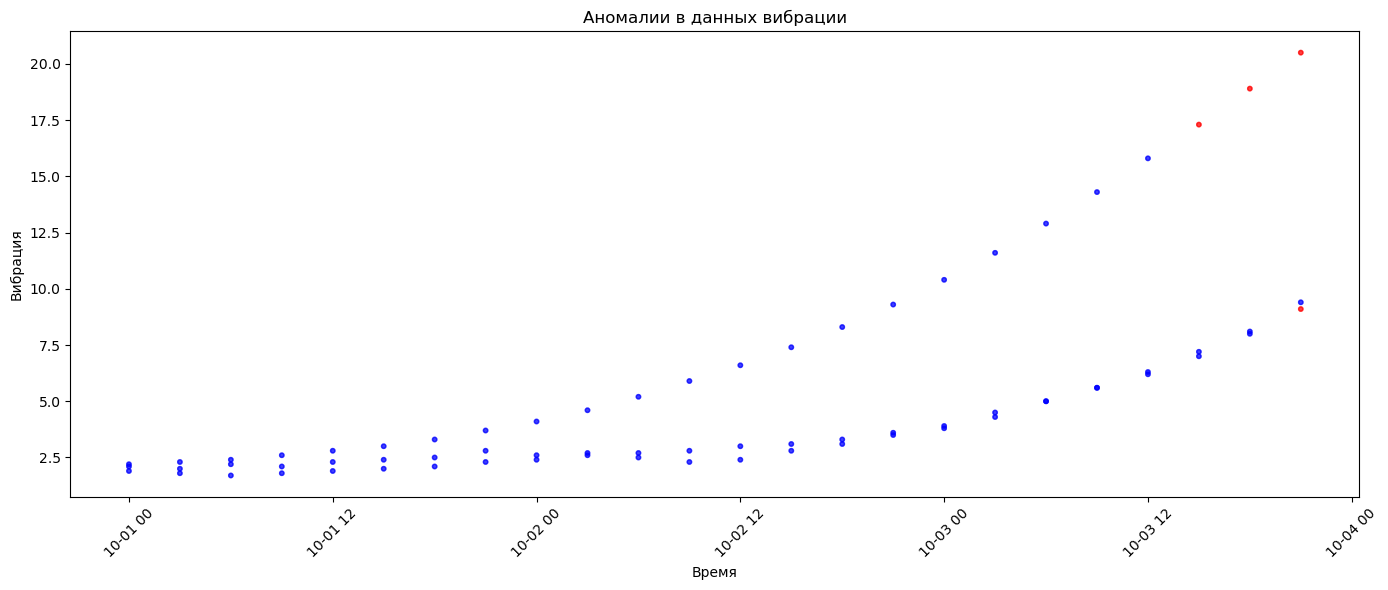

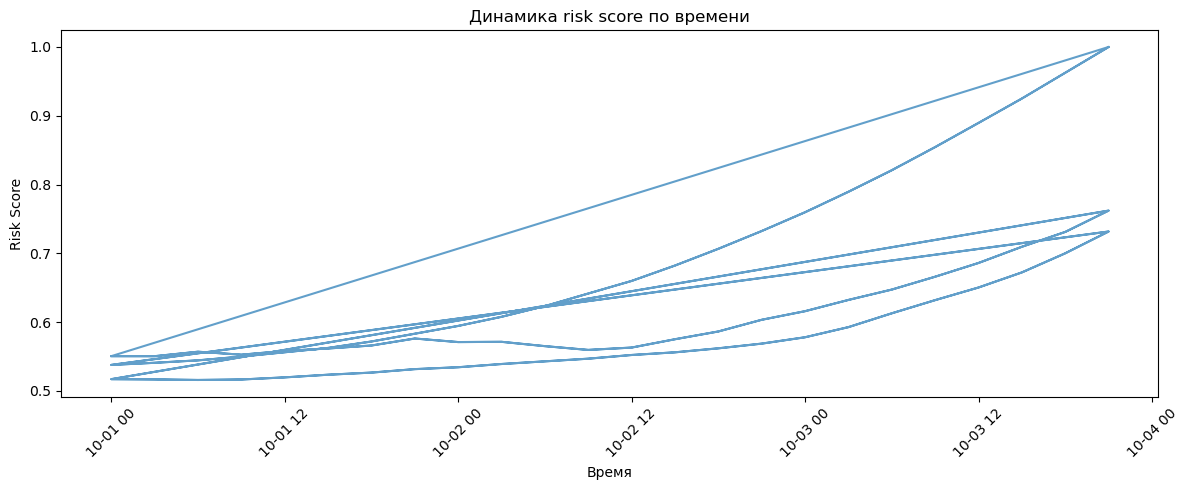

In [10]:
import pandas as pd
import numpy as np
import boto3
from io import BytesIO
from sklearn.ensemble import IsolationForest
import matplotlib.pyplot as plt

s3_client = boto3.client(
    's3',
    endpoint_url='http://minio:9000',
    aws_access_key_id='minioadmin',
    aws_secret_access_key='minioadmin',
    region_name='us-east-1'
)

bucket_name = 'oil-data'

def read_parquet_from_minio(key):
    obj = s3_client.get_object(Bucket=bucket_name, Key=key)
    return pd.read_parquet(BytesIO(obj['Body'].read()))

def read_partitioned_data(prefix):
    dfs = []
    response = s3_client.list_objects_v2(Bucket=bucket_name, Prefix=prefix)
    for obj in response.get('Contents', []):
        if obj['Key'].endswith('.parquet'):
            df = read_parquet_from_minio(obj['Key'])
            dfs.append(df)
    return pd.concat(dfs, ignore_index=True) if dfs else pd.DataFrame()

pump_sensors = read_partitioned_data('raw/pump_sensors/')
pump_failures = read_parquet_from_minio('raw/pump_failures/data.parquet')

features = ['vibration', 'temperature', 'current', 'rpm']
iso_forest = IsolationForest(contamination=0.05, random_state=42)
pump_sensors['anomaly'] = iso_forest.fit_predict(pump_sensors[features])

anomalies = pump_sensors[pump_sensors['anomaly'] == -1]
print(f"\nОбнаружено аномалий: {len(anomalies)} из {len(pump_sensors)}")

plt.figure(figsize=(14, 6))
colors = pump_sensors['anomaly'].map({1: 'blue', -1: 'red'})
plt.scatter(pump_sensors['timestamp'], pump_sensors['vibration'], c=colors, alpha=0.5, s=10)
plt.xlabel('Время')
plt.ylabel('Вибрация')
plt.title('Аномалии в данных вибрации')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('anomaly_detection.png')
plt.show()

pump_sensors['risk_score'] = (
    (pump_sensors['vibration'] / pump_sensors['vibration'].max()) * 0.4 +
    (pump_sensors['current'] / pump_sensors['current'].max()) * 0.3 +
    (pump_sensors['temperature'] / pump_sensors['temperature'].max()) * 0.3
)

plt.figure(figsize=(12, 5))
plt.plot(pd.to_datetime(pump_sensors['timestamp']), pump_sensors['risk_score'], alpha=0.7)
plt.xlabel('Время')
plt.ylabel('Risk Score')
plt.title('Динамика risk score по времени')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('risk_score.png')
plt.show()